In [1]:
# A very basic model for Lambert's problem in which, initially, we do not even consider gravity.

!python -m pip install lamberthub
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from datetime import datetime, timedelta
from lamberthub import gooding1990

def orbelem(rvec, vvec, mu):
    lvec = np.cross(rvec, vvec)  # [kg·m^2/s]
    r = np.linalg.norm(rvec)  # [m]
    v = np.linalg.norm(vvec)  # [m/s]
    l = np.linalg.norm(lvec)  # [m^2/s]
    evec = np.cross(vvec, lvec) / mu - rvec / r  # [-]
    e = np.linalg.norm(evec)  # [-]
    a = (l**2 / mu) / (1 - e**2)  # [m]
    i = np.arccos(lvec[2] / l)  # [rad]
    N = np.cross([0, 0, 1], lvec)  # [m^2/s]
    if N[1] >= 0:
        Omega = np.arccos(N[0] / np.linalg.norm(N))  # [rad]
    else:
        Omega = 2 * np.pi - np.arccos(N[0] / np.linalg.norm(N))  # [rad]

    if evec[2] >= 0:
        omega = np.arccos(np.dot(N / np.linalg.norm(N), evec / e))  # [rad]
    else:
        omega = 2 * np.pi - np.arccos(np.dot(N / np.linalg.norm(N), evec / e))  # [rad]

    vr = np.dot(rvec, vvec) / r  # [m/s]
    if vr >= 0:
        theta = np.arccos(np.dot(evec / e, rvec / r))  # [rad]
    else:
        theta = 2 * np.pi - np.arccos(np.dot(evec / e, rvec / r))  # [rad]

    return a, e, i, Omega, omega, theta, lvec

# Initial data about the orbit and phase (time)
LD = 400000000
G = 6.67408e-11
m = 100
Mearth = 5.972e24
muearth = G*Mearth
vorb = np.sqrt(muearth/LD)
year = 365.25*24*3600
AU = 1.495978707e11
rs = np.array([LD,
      0,
      0])
vs = np.array([0,
      vorb,
      0])
ts = datetime(2029,1,1,0,0,0)
Ps = 2*np.pi*np.sqrt(LD**3/muearth)

# Initial data about the asteroid's closest approach (JPL Horizons)
r1 = np.array([5.122567223204672e7,
      1.978360730206421e7,
      -1.149974804823440e8])
v1 = np.array([-5.820658659764865e3,
      4.152672117028012e3,
      -1.885857325167237e3])
t1 = datetime(2032,8,14,14,51,0)
a1, e1, i1, Omega1, omega1, theta01, lvec1 = orbelem(r1, v1, muearth)
r2 = np.array([-1.607806915037334e7,
      4.627326009909529e7,
      -1.648334768847444e8])
v2 = np.array([-7.476063202543985e3,
      -1.881110007343202e3,
      2.072765197439864e2])
t2 = datetime(2036,10,21,13,2,0)
a2, e2, i2, Omega2, omega2, theta02, lvec2 = orbelem(r2, v2, muearth)
r3 = np.array([9.308956501612067e7,
      5.687348043403940e7,
      -1.107827174570909e7])
v3 = np.array([1.259068680804511e3,
      -8.931269254496135e2,
      5.920514869298980e3])
t3 = datetime(2041,4,8,2,55,0)
a3, e3, i3, Omega3, omega3, theta03, lvec3 = orbelem(r3, v3, muearth)

# Thruster values
Isp = 3000;
g0 = 9.81;
m = 100;

# Time differences
dt1 = (t1-ts).total_seconds()
dt2 = (t2-t1).total_seconds()
dt3 = (t3-t2).total_seconds()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 2.0 MB/s eta 0:00:00


In [2]:
# Very preliminary computations even neglecting gravity (crazy)

# First maneuver: from GEO to closest approach of first asteroid
as1 = 2*(r1-rs-vs*dt1)/(dt1**2)
T1 = m*as1
DV1 = as1*dt1
vs1 = vs+DV1
vrel1 = vs1-v1
print(f"T1 = {np.linalg.norm(T1):0.2e} N, t1 = {dt1/3600/24/365.25:0.2f} years, vrel1 = {np.linalg.norm(vrel1)/1e3:0.2f} km/s")

# Second maneuver: from first asteroid closest approach to second
as2 = 2*(r2-r1-vs1*dt2)/(dt2**2)
T2 = m*as2
DV2 = as2*dt2
vs2 = vs1+DV2
vrel2 = vs2-v2
print(f"T2 = {np.linalg.norm(T2):0.2e} N, t2 = {dt2/3600/24/365.25:0.2f} years, vrel2 = {np.linalg.norm(vrel2)/1e3:0.2f} km/s")

# Third maneuver: from second asteroid closest approach to third
as3 = 2*(r3-r2-vs2*dt3)/(dt3**2)
T3 = m*as3
DV3 = as3*dt3
vs3 = vs2+DV3
vrel3 = vs3-v3
print(f"T3 = {np.linalg.norm(T3):0.2e} N, t3 = {dt3/3600/24/365.25:0.2f} years, vrel3 = {np.linalg.norm(vrel3)/1e3:0.2f} km/s")

T1 = 1.75e-03 N, t1 = 3.62 years, vrel1 = 7.99 km/s
T2 = 1.51e-03 N, t2 = 4.19 years, vrel2 = 8.02 km/s
T3 = 1.42e-03 N, t3 = 4.46 years, vrel3 = 6.05 km/s


In [3]:
# Previous computations with Lambert Transfer

def minimizedeltaV(mu, r1, r2, v1, v2, dt, prograde, AU, year, maxrev):
    i = 0; conv = False; DVmin = np.Inf
    while conv==False:
        try:
            v1_, v2_ = gooding1990(mu, r1, r2, dt, i, prograde)
            i += 1
            DV = v1_*AU/year-v1
            vrel = v2_*AU/year-v2
            if np.linalg.norm(DV) < DVmin:
                DVmin = np.linalg.norm(DV)
                vrelmin = np.linalg.norm(vrel)
            elif i <= maxrev and np.linalg.norm(DV) > DVmin:
                DVmin = np.linalg.norm(DV)
                vrelmin = np.linalg.norm(vrel)
            elif i >= maxrev and np.linalg.norm(DV) > DVmin:
                DV = DVmin
                vrel = vrelmin
                i -= 1
                conv = True
        except ValueError:
            conv = True

    return i, DV, vrel

# Conversion of units
muearth = muearth*year**2/AU**3
dt1 = dt1/year; dt2 = dt2/year; dt3 = dt3/year
rs = rs/AU; r1 = r1/AU; r2 = r2/AU; r3 = r3/AU
M1, DV1, vrel1 = minimizedeltaV(muearth, rs, r1, vs, v1, dt1, True, AU, year, 0)
M2, DV2, vrel2 = minimizedeltaV(muearth, r1, r2, v1+vrel1, v2, dt2, True, AU, year, 0)
M3, DV3, vrel3 = minimizedeltaV(muearth, r2, r3, v2+vrel2, v3, dt3, True, AU, year, 0)

In [4]:
print(f"1st Lamber transfer rev.: {M1}.")
print(f"1st Lambert burn: {np.linalg.norm(DV1)/1e3:0.4f} km/s.")
print(f"1st rel velocity: {np.linalg.norm(vrel1)/1e3:0.4f} km/s.")
print(f"2nd Lamber transfer rev.: {M2}.")
print(f"2nd Lambert burn: {np.linalg.norm(DV2)/1e3:0.4f} km/s.")
print(f"2nd rel velocity: {np.linalg.norm(vrel2)/1e3:0.4f} km/s.")
print(f"3rd Lamber transfer rev.: {M3}.")
print(f"3rd Lambert burn: {np.linalg.norm(DV3)/1e3:0.4f} km/s.")
print(f"3rd rel velocity: {np.linalg.norm(vrel3)/1e3:0.4f} km/s.\n")
print(f"Sum of Lambert burns and transfer time: {(np.linalg.norm(DV1)+np.linalg.norm(DV2)+np.linalg.norm(DV3))/1e3:0.4f} km/s and {(dt1+dt2+dt3):0.2f} years.")

1st Lamber transfer rev.: 108.
1st Lambert burn: 1.0292 km/s.
1st rel velocity: 6.3555 km/s.
2nd Lamber transfer rev.: 251.
2nd Lambert burn: 2.4727 km/s.
2nd rel velocity: 6.6777 km/s.
3rd Lamber transfer rev.: 2.
3rd Lambert burn: 7.5466 km/s.
3rd rel velocity: 7.5712 km/s.

Sum of Lambert burns and transfer time: 11.0485 km/s and 12.27 years.


In [5]:
# Manually design a maneuver to meet at the point of intersection with the ecliptic plane

def true_anomaly_through_radius(a, e, r):
    theta = np.arccos((1/e)*(a*(1-e**2)/r-1))
    return theta

def time_since_periapsis_hyperbolic(theta, a, e, mu):
    if e <= 1 or a >= 0:
        raise ValueError("Invalid parameters: Hyperbolic orbits require e > 1 and a < 0.")
    # Make sure the true anomaly is a np array
    theta = np.asarray(theta)
    # Compute the hyperbolic anomaly (H)
    sinh_H = (e + np.cos(theta)) / np.sqrt(e**2 - 1)
    H = np.arcsinh(sinh_H)
    # Compute the time since periapsis
    n = np.sqrt(mu / abs(a)**3)  # Mean motion (for hyperbolic orbit)
    t = (e * np.sinh(H) - H) / n
    # Assign negative time to negative true anomalies
    t[theta < 0] *= -1
    return t

def orbital_elements_to_state_vectors(a, e, i, Omega, omega, nu_array, mu):
    nu_array = np.asarray(nu_array)  # Ensure input is a NumPy array
    # Compute semi-latus rectum
    p = a * (1 - e**2)
    # Compute radius for each true anomaly
    r_array = p / (1 + e * np.cos(nu_array))
    # Compute position in perifocal coordinates (PQW)
    r_pqw = np.column_stack((r_array * np.cos(nu_array),
                             r_array * np.sin(nu_array),
                             np.zeros_like(nu_array)))
    # Compute velocity in perifocal coordinates (PQW)
    sqrt_mu_p = np.sqrt(mu / p)
    v_pqw = np.column_stack((-sqrt_mu_p * np.sin(nu_array),
                              sqrt_mu_p * (e + np.cos(nu_array)),
                              np.zeros_like(nu_array)))
    # Rotation matrices
    cos_Omega, sin_Omega = np.cos(Omega), np.sin(Omega)
    cos_i, sin_i = np.cos(i), np.sin(i)
    cos_omega, sin_omega = np.cos(omega), np.sin(omega)
    # Full transformation matrix (3-1-3 Euler angles)
    rotation_matrix = np.array([
        [cos_Omega * cos_omega - sin_Omega * sin_omega * cos_i,
         -cos_Omega * sin_omega - sin_Omega * cos_omega * cos_i,
         sin_Omega * sin_i],
        [sin_Omega * cos_omega + cos_Omega * sin_omega * cos_i,
         -sin_Omega * sin_omega + cos_Omega * cos_omega * cos_i,
         -cos_Omega * sin_i],
        [sin_omega * sin_i,
         cos_omega * sin_i,
         cos_i]
    ])
    # Transform position and velocity to inertial frame
    r_vectors = np.dot(r_pqw, rotation_matrix.T)
    v_vectors = np.dot(v_pqw, rotation_matrix.T)
    return r_vectors, v_vectors

def find_closest_z_crossing_state(r_vectors, v_vectors, time_vector, target_radius):
    z_values = r_vectors[:, 2]  # Extract the z-coordinates
    crossing_data = []  # Store tuples of (t_cross, r_cross, v_cross, r_magnitude)
    # Iterate through consecutive points to find z-crossings
    for i in range(len(z_values) - 1):
        z1, z2 = z_values[i], z_values[i + 1]
        t1, t2 = time_vector[i], time_vector[i + 1]
        r1, r2 = r_vectors[i], r_vectors[i + 1]  # Position vectors
        v1, v2 = v_vectors[i], v_vectors[i + 1]  # Velocity vectors
        r1_mag, r2_mag = np.linalg.norm(r1), np.linalg.norm(r2)  # Compute radii
        # Check for sign change (crossing)
        if z1 * z2 < 0:  # One is positive, one is negative
            # Linear interpolation factor
            alpha = (0 - z1) / (z2 - z1)
            # Interpolated time
            t_cross = t1 + alpha * (t2 - t1)
            # Interpolated position and velocity vectors
            r_cross = r1 + alpha * (r2 - r1)
            v_cross = v1 + alpha * (v2 - v1)
            # Interpolated radius
            r_cross_mag = np.linalg.norm(r_cross)
            # Store crossing data
            crossing_data.append((t_cross, r_cross, v_cross, r_cross_mag))
    if not crossing_data:
        return None  # No crossing found
    # Find the crossing with radius closest to the target
    closest_crossing = min(crossing_data, key=lambda x: abs(x[3] - target_radius))
    # Extract results
    t_cross, r_cross, v_cross, _ = closest_crossing
    return t_cross, r_cross, v_cross

def modify_date_by_offset(closest_approach_date, time_offset):
    return closest_approach_date + timedelta(seconds=time_offset)

muearth = G*Mearth
# First asteroid encounter
thetai1 = true_anomaly_through_radius(a1,e1,7*LD)
thetap1 = np.linspace(-thetai1,thetai1,10000)
t1p = time_since_periapsis_hyperbolic(thetap1,a1,e1,muearth)
r1r,v1r = orbital_elements_to_state_vectors(a1,e1,i1,Omega1,omega1,thetap1,muearth)
t1c, r1c, v1c = find_closest_z_crossing_state(r1r,v1r,t1p,LD)
date1c = modify_date_by_offset(t1,t1c)
print(f"Ast#1 - Time after perigee: {t1c/3600:0.2f} h, "
      f"Modified date: {date1c.strftime('%Y-%m-%d %H:%M:%S')} UTC;\n"
      f"        State vector: [{r1c[0]:0.2e},{r1c[1]:0.2e},{r1c[2]:0.2f}] m, "
      f"[{v1c[0]:0.2f},{v1c[1]:0.2f},{v1c[2]:0.2f}] m/s.")

# Second asteroid encounter
thetai2 = true_anomaly_through_radius(a2,e2,7*LD)
thetap2 = np.linspace(-thetai2,thetai2,10000)
t2p = time_since_periapsis_hyperbolic(thetap2,a2,e2,muearth)
r2r,v2r = orbital_elements_to_state_vectors(a2,e2,i2,Omega2,omega2,thetap2,muearth)
t2c, r2c, v2c = find_closest_z_crossing_state(r2r,v2r,t2p,LD)
date2c = modify_date_by_offset(t2,t2c)
print(f"Ast#2 - Time after perigee: {t2c/3600:0.2f} h, "
      f"Modified date: {date2c.strftime('%Y-%m-%d %H:%M:%S')} UTC;\n"
      f"        State vector: [{r2c[0]:0.2e},{r2c[1]:0.2e},{r2c[2]:0.2f}] m, "
      f"[{v2c[0]:0.2f},{v2c[1]:0.2f},{v2c[2]:0.2f}] m/s.")

# Third asteroid encounter
thetai3 = true_anomaly_through_radius(a3,e3,5*LD)
thetap3 = np.linspace(-thetai3,thetai3,10000)
t3p = time_since_periapsis_hyperbolic(thetap3,a3,e3,muearth)
r3r,v3r = orbital_elements_to_state_vectors(a3,e3,i3,Omega3,omega3,thetap3,muearth)
t3c,r3c,v3c = find_closest_z_crossing_state(r3r,v3r,t3p,LD)
date3c = modify_date_by_offset(t3,t3c)
print(f"Ast#3 - Time after perigee: {t3c/3600:0.2f} h, "
      f"Modified date: {date3c.strftime('%Y-%m-%d %H:%M:%S')} UTC;\n"
      f"        State vector: [{r3c[0]:0.2e},{r3c[1]:0.2e},{r3c[2]:0.2f}] m, "
      f"[{v3c[0]:0.2f},{v3c[1]:0.2f},{v3c[2]:0.2f}] m/s.")

Ast#1 - Time after perigee: -5.22 h, Modified date: 2032-08-14 09:37:43 UTC;
        State vector: [3.52e+08,-2.02e+08,0.00] m, [-5414.24,4042.80,-2174.87] m/s.
Ast#2 - Time after perigee: 6.50 h, Modified date: 2036-10-21 19:31:43 UTC;
        State vector: [-2.53e+09,-6.16e+08,0.00] m, [-7164.53,-1890.70,487.63] m/s.
Ast#3 - Time after perigee: 6.28 h, Modified date: 2041-04-08 09:11:38 UTC;
        State vector: [9.54e+07,5.52e+07,0.00] m, [1206.04,-924.65,5923.64] m/s.


In [22]:
def compute_transfer_time_and_delta_v(v_initial, mu, r_asteroid, r_orbit):
    # Compute the opposed position vector
    r_opposed = -r_asteroid*r_orbit/np.linalg.norm(r_asteroid)
    v_opposed = v_initial*np.array([-r_opposed[1],r_opposed[0],0])/np.linalg.norm(r_opposed);
    # Compute magnitudes of the position vectors
    r1 = np.linalg.norm(r_asteroid)
    r2 = np.linalg.norm(r_opposed)
    # Compute the semi-major axis of the transfer orbit
    a = (r1 + r2) / 2
    if r1 < r2:
        e = 1 - r1/a
    elif r1 > r2:
        e = 1 - r2/a
    else:
        e = 0
    # Compute the velocity at the initial position in the transfer orbit using vis-viva
    v_transfer = np.sqrt(mu * (2 / r2 - 1 / a))
    # Compute the required delta-v
    delta_v = abs(v_transfer - v_initial)
    # Compute the transfer time (half of the full orbital period)
    transfer_time = np.pi * np.sqrt(a**3 / mu)
    return r_opposed, v_opposed, transfer_time, delta_v, a, e

def compute_transfer_start_date_and_true_anomalies(r_orbit, initial_epoch, transfer_time, visit_date, mu):
    # Compute the transfer start date
    transfer_start_date = visit_date - timedelta(seconds=transfer_time)
    # Compute the orbital radius (since the orbit is circular, this is just the magnitude of r_orbit)
    r = np.linalg.norm(r_orbit)
    # Compute the mean motion (rad/s)
    mean_motion = np.sqrt(mu / r**3)
    # Compute the elapsed time since the initial epoch to the transfer start date
    elapsed_time = (transfer_start_date - initial_epoch).total_seconds()
    # Compute the true anomaly at the transfer start date
    true_anomaly_transfer_start = np.arctan2(r_orbit[1],r_orbit[0])
    # Compute the true anomaly of the spacecraft evolved from the initial epoch
    true_anomaly_evolved = (mean_motion * elapsed_time) % (2 * np.pi)
    # Compute difference in true anomaly
    Dtheta = true_anomaly_evolved - true_anomaly_transfer_start
    if Dtheta > np.pi:
        Dtheta -= 2 * np.pi
    return Dtheta, transfer_start_date, true_anomaly_transfer_start

def compute_phase_dv(phase_difference, max_time, r_circular, mu):
    # Compute mean motion of the initial orbit
    n = np.sqrt(mu / r_circular**3)
    # Compute the total angular displacement needed
    delta_theta = phase_difference
    # Compute required semi-major axis using the phasing equation
    n_revs = np.floor(max_time / (2 * np.pi / n))  # Maximum number of orbits allowed
    delta_t = -delta_theta / n + (2 * np.pi * n_revs) / n  # Time for phasing
    a_transfer = (mu * (delta_t / (2 * np.pi * n_revs))**2)**(1/3)  # Semi-major axis of phasing orbit
    if a_transfer < r_circular:
        e_transfer = r_circular/a_transfer-1
    else:
        e_transfer = 1-r_circular/a_transfer
    # Compute velocity changes using vis-viva equation
    v_circular = np.sqrt(mu / r_circular)
    v_transfer = np.sqrt(mu * (2 / r_circular - 1 / a_transfer))
    # Determine ΔV based on the sign of the phase difference
    if phase_difference > 0:
        # Target trails: Increase velocity at start, decrease at end
        dv_i = v_transfer - v_circular
        dv_f = -(v_transfer - v_circular)
    else:
        # Target leads: Decrease velocity at start, increase at end
        dv_i = -(v_transfer - v_circular)
        dv_f = v_transfer - v_circular
    total_dv = abs(dv_i) + abs(dv_f)
    return total_dv, delta_t, n_revs, a_transfer, e_transfer

def transfer_correction(a, r_opposed, v_opposed, r_asteroid, transfer_time, Isp, g0, mu, m):
    # Burn duration as 1/20th of the orbital period
    orbital_period = 2*np.pi*np.sqrt(a**3/mu)
    burn_duration = orbital_period / 20
    # Estimate phase correction in time
    mean_motion = 2 * np.pi / orbital_period  # Mean motion (rad/s)
    phase_correction = -(burn_duration / 2) * mean_motion  # Approximate phase shift in seconds
    Rz = np.array([
        [np.cos(phase_correction), -np.sin(phase_correction), 0],
        [np.sin(phase_correction),  np.cos(phase_correction), 0],
        [0,              0,             1]
    ])
    r1 = Rz @ r_opposed
    v1 = Rz @ v_opposed
    r2 = r_asteroid
    dt = transfer_time + burn_duration/2
    v1_, v2_ = gooding1990(mu, r1, r2, dt, 0, True)
    delta_v = np.linalg.norm(v1_-v1);
    # Calculate mass flow rate from the rocket equation
    exhaust_velocity = Isp * g0
    alpha = np.exp(delta_v/exhaust_velocity)
    mass_flow_rate = m*(alpha-1)/(alpha*burn_duration)
    # Calculate thrust (T = m_dot * Ve)
    thrust = mass_flow_rate * exhaust_velocity
    return thrust, phase_correction, delta_v, dt

def phase_correction(a, atrans, etrans, vorb, transfer_time, n_revs, Isp, g0, mu, m):
    # Burn duration as 1/20th of the orbital period
    orbital_period = 2*np.pi*np.sqrt(a**3/mu)
    burn_duration = orbital_period / 20
    # Estimate phase correction in time
    mean_motion = 2 * np.pi / orbital_period  # Mean motion (rad/s)
    phase_correction = -(burn_duration / 2) * mean_motion  # Approximate phase shift in seconds
    Rz = np.array([
        [np.cos(phase_correction), -np.sin(phase_correction), 0],
        [np.sin(phase_correction),  np.cos(phase_correction), 0],
        [0,              0,             1]
    ])
    r1 = Rz @ np.array([a, 0, 0])
    v1 = Rz @ np.array([0, vorb, 0])
    if atrans > a:
        r = -atrans*(1+etrans)
    else:
        r = -atrans*(1-etrans)
    r2 = np.array([r, 0, 0])
    dt = transfer_time/(2*n_revs) + burn_duration/2
    v1_, v2_ = gooding1990(mu, r1, r2, dt, 0, True)
    delta_v = 2*np.linalg.norm(v1_-v1);
    # Calculate mass flow rate from the rocket equation
    exhaust_velocity = Isp * g0
    alpha = np.exp(delta_v/exhaust_velocity)
    mass_flow_rate = m*(alpha-1)/(alpha*burn_duration)
    # Calculate thrust (T = m_dot * Ve)
    thrust = mass_flow_rate * exhaust_velocity
    return thrust, phase_correction, delta_v, transfer_time+burn_duration/2

# Computation of transfer times and delta_v for visiting maneuvers
rorb1, vorb1, dtv1, DV1v, at1, et1 = compute_transfer_time_and_delta_v(vorb, muearth, r1c, LD)
thrust1, theta1vc, DV1vc, dtvc1 = transfer_correction(LD, rorb1, vorb1, r1c, dtv1, Isp, g0, muearth, m)
date1a = modify_date_by_offset(date1c,dtv1)
print(f"Visiting Ast#1 - Transfer times: {dtv1/3600/24:0.2f},{dtvc1/3600/24:0.2f} days, Impulse costs: {DV1v:0.2f},{DV1vc:0.2f} m/s, Thrust: {thrust1*1e3:0.2f} mN.")
rorb2, vorb2, dtv2, DV2v, at2, et2 = compute_transfer_time_and_delta_v(vorb, muearth, r2c, LD)
thrust2, theta2vc, DV2vc, dtvc2 = transfer_correction(LD, rorb2, vorb2, r2c, dtv2, Isp, g0, muearth, m)
date2a = modify_date_by_offset(date2c,dtv2)
print(f"Visiting Ast#2 - Transfer times: {dtv2/3600/24:0.2f},{dtvc2/3600/24:0.2f} days, Impulse costs: {DV2v:0.2f},{DV2vc:0.2f} m/s, Thrust: {thrust2*1e3:0.2f} mN.")
rorb3, vorb3, dtv3, DV3v, at3, et3 = compute_transfer_time_and_delta_v(vorb, muearth, r3c, LD)
thrust3, theta3vc, DV3vc, dtvc3 = transfer_correction(LD, rorb3, vorb3, r3c, dtv3, Isp, g0, muearth, m)
print(f"Visiting Ast#3 - Transfer times: {dtv3/3600/24:0.2f},{dtvc3/3600/24:0.2f} days, Impulse costs: {DV3v:0.2f},{DV3vc:0.2f} m/s, Thrust: {thrust3*1e3:0.2f} mN.\n")

# Computation of phasing required maneuvers
Dtheta1, tr1sd, thetav1 = compute_transfer_start_date_and_true_anomalies(rorb1, ts, dtv1, date1c, muearth)
maxt1 = (tr1sd-ts).total_seconds()
DVp1, dtp1, n1, ap1, ep1 = compute_phase_dv(Dtheta1, maxt1, LD, muearth)
thrustp1, phasepc1, DVpc1, dtpc1 = phase_correction(LD, ap1, ep1, vorb, dtp1, n1, Isp, g0, muearth, m)
print(f"Phasing Ast#1 - Phasing times: {dtp1/3600/24/365.25:0.2f},{dtpc1/3600/24/365.25:0.2f} years, Total costs: {DVp1:0.2f},{DVpc1:0.2f} m/s, Number of revolutions: {n1:0.0f}, Thrust: {thrustp1*1e3:0.2f} mN.")
Dtheta2, tr2sd, thetav2 = compute_transfer_start_date_and_true_anomalies(rorb2, date1a, dtv2, date2c, muearth)
maxt2 = (tr2sd-date1a).total_seconds()
DVp2, dtp2, n2, ap2, ep2 = compute_phase_dv(Dtheta2, maxt2, LD, muearth)
thrustp2, phasepc2, DVpc2, dtpc2 = phase_correction(LD, ap2, ep2, vorb, dtp2, n2, Isp, g0, muearth, m)
print(f"Phasing Ast#2 - Phasing times: {dtp2/3600/24/365.25:0.2f},{dtpc2/3600/24/365.25:0.2f} years, Total costs: {DVp2:0.2f},{DVpc2:0.2f} m/s, Number of revolutions: {n2:0.0f}, Thrust: {thrustp2*1e3:0.2f} mN.")
Dtheta3, tr3sd, thetav3 = compute_transfer_start_date_and_true_anomalies(rorb3, date2a, dtv3, date3c, muearth)
maxt3 = (tr3sd-date2a).total_seconds()
DVp3, dtp3, n3, ap3, ep3 = compute_phase_dv(Dtheta3, maxt3, LD, muearth)
thrustp3, phasepc3, DVpc3, dtpc3 = phase_correction(LD, ap3, ep3, vorb, dtp3, n3, Isp, g0, muearth, m)
print(f"Phasing Ast#3 - Phasing times: {dtp3/3600/24/365.25:0.2f},{dtpc3/3600/24/365.25:0.2f} years, Total costs: {DVp3:0.2f},{DVpc3:0.2f} m/s, Number of revolutions: {n3:0.0f}, Thrust: {thrustp3*1e3:0.2f} mN.\n")

# Total cost of each asteroid visit compared to closest approach
DV1T = 2*DV1v + DVp1; Dt1T = maxt1 + 2*dtv1
DV1Tc = 2*DV1vc + DVpc1; Dt1Tc = maxt1 + 2*dtv1
print(f"Total effort to visit Ast#1: {DV1T:0.2f},{DV1Tc:0.2f} m/s ({DV1T/np.linalg.norm(DV1)*100:0.2f},{DV1Tc/np.linalg.norm(DV1)*100:0.2f} %) and {Dt1T/3600/24/365.25:0.2f},{Dt1Tc/3600/24/365.25:0.2f} years ({Dt1T/dt1/year*100:0.2f},{Dt1Tc/dt1/year*100:0.2f} %).")
DV2T = 2*DV2v + DVp2; Dt2T = maxt2 + 2*dtv2
DV2Tc = 2*DV2vc + DVpc2; Dt2Tc = maxt2 + 2*dtv2
print(f"Total effort to visit Ast#2: {DV2T:0.2f},{DV2Tc:0.2f} m/s ({DV2T/np.linalg.norm(DV2)*100:0.2f},{DV2Tc/np.linalg.norm(DV2)*100:0.2f} %) and {Dt2T/3600/24/365.25:0.2f},{Dt2Tc/3600/24/365.25:0.2f} years ({Dt2T/dt2/year*100:0.2f},{Dt2Tc/dt2/year*100:0.2f} %).")
DV3T = 2*DV3v + DVp3; Dt3T = maxt3 + 2*dtv3
DV3Tc = 2*DV3vc + DVpc3; Dt3Tc = maxt3 + 2*dtv3
print(f"Total effort to visit Ast#3: {DV3T:0.2f},{DV3Tc:0.2f} m/s ({DV3T/np.linalg.norm(DV3)*100:0.2f},{DV3Tc/np.linalg.norm(DV3)*100:0.2f} %) and {Dt3T/3600/24/365.25:0.2f},{Dt3Tc/3600/24/365.25:0.2f} years ({Dt3T/dt3/year*100:0.2f},{Dt3Tc/dt3/year*100:0.2f} %).\n")
DVTT = DV1T + DV2T + DV3T; DtTT = Dt1T + Dt2T + Dt3T
DVTTc = DV1Tc + DV2Tc + DV3Tc; DtTTc = Dt1Tc + Dt2Tc + Dt3Tc
print(f"Total effort: {DVTT:0.2f},{DVTTc:0.2f} m/s ({DVTT/(np.linalg.norm(DV1)+np.linalg.norm(DV2)+np.linalg.norm(DV3))*100:0.2f},{DVTTc/(np.linalg.norm(DV1)+np.linalg.norm(DV2)+np.linalg.norm(DV3))*100:0.2f} %) and {DtTT/3600/24/365.25:0.2f},{DtTTc/3600/24/365.25:0.2f} years ({DtTT/(dt1+dt2+dt3)/year*100:0.2f},{DtTTc/(dt1+dt2+dt3)/year*100:0.2f} %).")

Visiting Ast#1 - Transfer times: 14.74,15.47 days, Impulse costs: 3.84,3.96 m/s, Thrust: 3.14 mN.
Visiting Ast#2 - Transfer times: 106.22,106.95 days, Impulse costs: 316.26,325.02 m/s, Thrust: 256.76 mN.
Visiting Ast#3 - Transfer times: 7.42,8.15 days, Impulse costs: 342.13,350.89 m/s, Thrust: 277.08 mN.

Phasing Ast#1 - Phasing times: 3.48,3.48 years, Total costs: 6.45,6.65 m/s, Number of revolutions: 44, Thrust: 5.28 mN.
Phasing Ast#2 - Phasing times: 3.81,3.81 years, Total costs: 4.11,4.24 m/s, Number of revolutions: 48, Thrust: 3.36 mN.
Phasing Ast#3 - Phasing times: 4.11,4.12 years, Total costs: 5.65,5.82 m/s, Number of revolutions: 52, Thrust: 4.62 mN.

Total effort to visit Ast#1: 14.14,14.57 m/s (1.37,1.42 %) and 3.66,3.66 years (101.10,101.10 %).
Total effort to visit Ast#2: 636.63,654.28 m/s (25.75,26.46 %) and 4.44,4.44 years (106.02,106.02 %).
Total effort to visit Ast#3: 689.90,707.60 m/s (9.14,9.38 %) and 4.19,4.19 years (93.94,93.94 %).

Total effort: 1340.67,1376.44 m/s

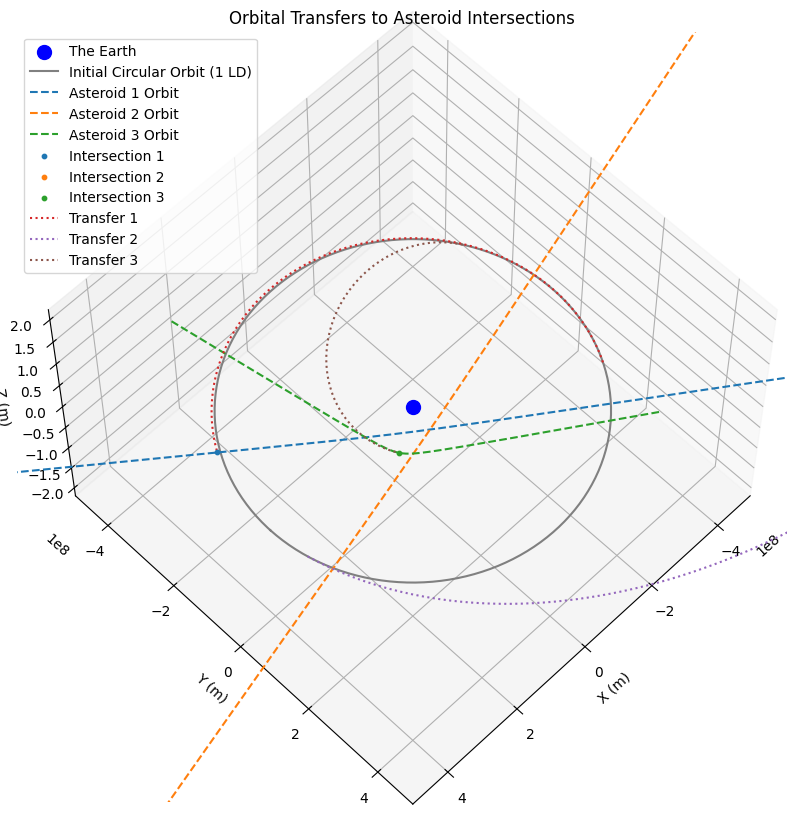

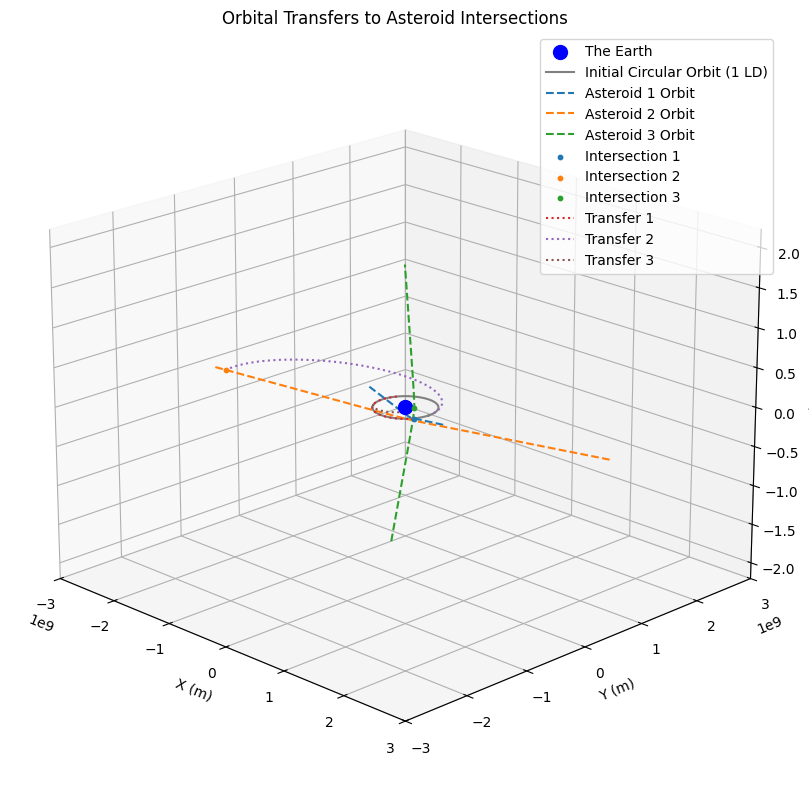

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_orbits(initial_orbit_radius, asteroid_orbits, intersection_points, transfer_orbits, lim_val, elev, azim):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection="3d")
    # Plot the initial circular orbit (1 LD)
    theta = np.linspace(0, 2*np.pi, 300)
    x_init = initial_orbit_radius * np.cos(theta)
    y_init = initial_orbit_radius * np.sin(theta)
    z_init = np.zeros_like(theta)  # Equatorial orbit
    ax.scatter(0, 0, 0, s=100, color='b', label="The Earth")
    ax.plot(x_init, y_init, z_init, 'gray', label="Initial Circular Orbit (1 LD)")
    # Plot asteroid orbits
    for i, orbit in enumerate(asteroid_orbits):
        ax.plot(orbit[:, 0], orbit[:, 1], orbit[:, 2], label=f"Asteroid {i+1} Orbit", linestyle="dashed")
    # Plot intersection points
    for i, point in enumerate(intersection_points):
        ax.scatter(point[0], point[1], point[2], s=10, label=f"Intersection {i+1}")
    # Plot transfer orbits
    for i, transfer in enumerate(transfer_orbits):
        ax.plot(transfer[:, 0], transfer[:, 1], transfer[:, 2], label=f"Transfer {i+1}", linestyle="dotted")
    # Labels and view adjustments
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.set_zlabel("Z (m)")
    ax.set_xlim(-lim_val, lim_val)
    ax.set_ylim(-lim_val, lim_val)
    ax.set_title("Orbital Transfers to Asteroid Intersections")
    ax.legend()
    ax.grid(True)
    ax.view_init(elev,azim)
    plt.show()

# Asteroids orbits
asteroid_orbits = [np.array(r1r),np.array(r2r),np.array(r3r)]

# Intersection points (z = 0 crossings)
intersection_points = [np.array(r1c),np.array(r2c),np.array(r3c)]

# Computation of transfer orbits to targets
nu_array1 = np.linspace(0,np.pi,10000)
nu_array2 = np.linspace(np.pi,2*np.pi,10000)
rt1, vt1 = orbital_elements_to_state_vectors(at1, et1, 0, 0, thetav1, nu_array1, muearth)
rt2, vt2 = orbital_elements_to_state_vectors(at2, et2, 0, 0, thetav2, nu_array1, muearth)
rt3, vt3 = orbital_elements_to_state_vectors(at3, et3, 0, 0, thetav3+np.pi, nu_array2, muearth)
transfer_orbits = [np.array(rt1),np.array(rt2),np.array(rt3)]

# Generate the plot
elev1 = 60; azim1 = 45
elev2 = 20; azim2 = -45
plot_orbits(LD, asteroid_orbits, intersection_points, transfer_orbits, 5e8, elev1, azim1)
plot_orbits(LD, asteroid_orbits, intersection_points, transfer_orbits, 3e9, elev2, azim2)